# Phytoplankton biomass variability budget

In [58]:
from smode_import import *

### Budget equation:
$\frac{1}{P}\frac{D_h P}{Dt} = G - \Gamma - w \frac{\partial P}{\partial z}$

### $P(G-\Gamma)$ Growth minus Grazing

In [62]:
# load biology data
biology_data = xr.open_dataset('biology_data.nc').sel(time=slice('2023-04-18','2023-04-24'))
biology_data = biology_data.where(biology_data.growth >= 0, drop=True)

# filter to take depth 5 unless there is none, take depth 10
cast_counts = biology_data['cast'].to_pandas().value_counts()
duplicate_casts = cast_counts[cast_counts > 1].index
mask = (biology_data['cast'].isin(duplicate_casts)) & (biology_data['depth'] != 5)
filtered_biology_data = biology_data.where(~mask, drop=True)
#biology_data = filtered_biology_data

# load eddy core position and composite 
ds_interpolated = xr.open_dataset('eddy_core_position.nc')
eddy_composite = xr.open_dataset('composite_eddy.nc')
x_eddy, y_eddy = eddy_composite.x_eddy, eddy_composite.y_eddy

ds_interpolated_on_grazing = ds_interpolated.interp(time=biology_data.time,
                                                        method='quadratic',
                                                        kwargs={"fill_value": "extrapolate"})

# find distance in latitude and longitude for each time step
dlat = ds_interpolated_on_grazing.lat - biology_data.lat
dlon = ds_interpolated_on_grazing.lon - biology_data.lon

# convert distance into km
dy_km = dlat * 111320 / 1e3
dx_km = dlon * (111320 * np.cos(np.radians(ds_interpolated_on_grazing.lat.values))) / 1e3
dist_from_core = np.sqrt(dx_km**2 + dy_km**2)

eddy_biology = xr.Dataset(
    {
    'grazing': xr.DataArray(biology_data.grazing.values,dims='dist_from_core'),
    'growth': xr.DataArray(biology_data.growth.values,dims='dist_from_core'),
    'chl_a': xr.DataArray(biology_data.chl_a.values,dims='dist_from_core'),
    'dist_from_core': xr.DataArray(dist_from_core),
    'lat': xr.DataArray(biology_data.lat.values,dims='dist_from_core'),
    'lon': xr.DataArray(biology_data.lon.values,dims='dist_from_core'),
    'depth': xr.DataArray(biology_data.depth.values,dims='dist_from_core'),
    'grazing_se': xr.DataArray(biology_data.grazing_se.values,dims='dist_from_core'),
    'growth_se': xr.DataArray(biology_data.growth_se.values,dims='dist_from_core'),
    },
)
eddy_biology = eddy_biology.sortby('dist_from_core')
eddy_biology = eddy_biology#.isel(dist_from_core = [1], time = [1])
eddy_biology#.to_netcdf('eddy_biology.nc')

<xarray.Dataset> Size: 960B
Dimensions:         (dist_from_core: 12, time: 12)
Coordinates:
  * time            (time) datetime64[ns] 96B 2023-04-19T11:30:00 ... 2023-04...
    dist_from_core  (time) float64 96B 0.8612 2.287 2.287 ... 39.52 41.59 41.59
Data variables:
    grazing         (dist_from_core) float64 96B -0.585 -2.458 ... -0.8734
    growth          (dist_from_core) float64 96B 0.6086 1.368 ... 1.399 1.217
    chl_a           (dist_from_core) float64 96B 2.156 3.183 ... 1.956 2.548
    lat             (dist_from_core) float64 96B 37.04 36.98 ... 36.81 36.81
    lon             (dist_from_core) float64 96B -123.9 -123.9 ... -124.2 -124.2
    depth           (dist_from_core) float64 96B 5.0 10.0 10.0 ... 5.0 5.0 10.0
    grazing_se      (dist_from_core) float64 96B 0.5977 0.2352 ... 0.09824
    growth_se       (dist_from_core) float64 96B 0.3644 0.1435 ... 0.06983

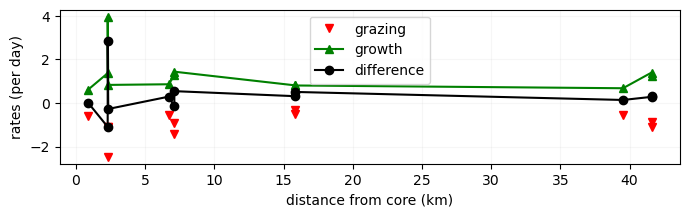

9.0
11.0
12.0
13.0
13.0
15.0
15.0
16.0
16.0
17.0
20.0
20.0


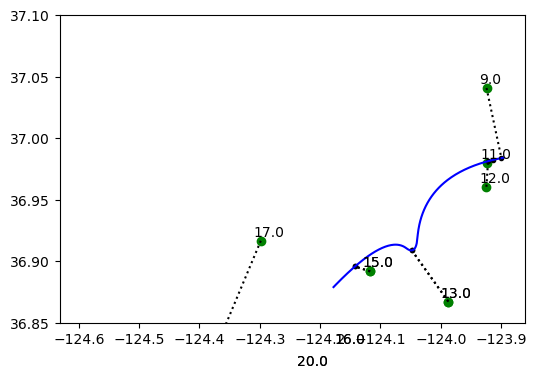

In [64]:
# growth and grazing from eddy core
plt.figure(figsize=(8,2))
plt.plot(eddy_biology.dist_from_core,eddy_biology.grazing,'vr',label='grazing')
plt.plot(eddy_biology.dist_from_core,eddy_biology.growth,'^-g',label='growth')
plt.plot(eddy_biology.dist_from_core,eddy_biology.growth+eddy_biology.grazing,'o-k',label='difference')
plt.xlabel('distance from core (km)')
plt.ylabel('rates (per day)')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

plt.figure(figsize=(6,4))
for i in range(biology_data.time.shape[0]):
    x=biology_data.lon.values[i]
    y=biology_data.lat.values[i]
    cast=str(biology_data.cast.values[i])
    plt.text(x*1.0001,y*1.0001,cast)
    print(cast)

plt.plot(biology_data.lon, biology_data.lat, 'og')

plt.plot([biology_data.lon, ds_interpolated_on_grazing.lon],
         [biology_data.lat, ds_interpolated_on_grazing.lat], ':k')

plt.plot(ds_interpolated_on_grazing.lon,
         ds_interpolated_on_grazing.lat,'.k')
plt.plot(ds_interpolated.lon,
         ds_interpolated.lat,'-b')
plt.ylim(36.85, 37.1)
plt.show()

In [65]:
#eddy_biology.growth.plot(marker='o',figsize=(6,2))
#eddy_biology.dist_from_core.plot(marker='o',figsize=(6,2));

## $\frac{D_hP}{Dt}$ Chlorophyll Rate of Change

cast(s) [ 0.9  2.3  2.3  2.3  6.7  7.1  7.1 15.8 15.8 39.5 41.6 41.6] km from eddy core


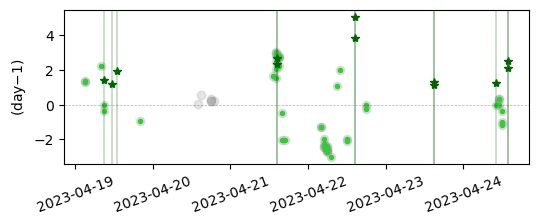

In [69]:
dChldt_dataset = xr.open_dataset('dChldt_from_core.nc')#.dChldt
dChldt_dataset

# only keep data points near grazing values
biology_data = xr.open_dataset('biology_data.nc').sel(time=slice('2023-04-18','2023-04-24'))
grazing_times = eddy_biology.time

time_array = dChldt_dataset.time
delta = np.timedelta64(12, 'h')

# Find indices where time_array is within ±30 min of any grazing time
indices = np.where(
    (time_array >= grazing_times - delta) &
    (time_array <= grazing_times + delta)
)[0]

indices = np.unique(indices)

plt.figure(figsize=(6,2))
plt.plot(dChldt_dataset.time, dChldt_dataset.dChldt ,'o',color='grey', alpha=0.2)

dChldt_dataset = dChldt_dataset.isel(dist_from_core=indices)
dChldt_dataset

plt.plot(dChldt_dataset.time, dChldt_dataset.dChldt ,'.',color='limegreen')
plt.plot(eddy_biology.time,(eddy_biology.growth-eddy_biology.grazing),'*',color='darkgreen')
for t in eddy_biology.time.values:
    plt.axvline(t, linestyle='-', color='darkgreen', lw=0.3)
plt.xticks(rotation=20)
plt.ylabel('(day${-1}$)')
plt.axhline(0,linestyle='--',color='k',alpha=0.3,linewidth=0.5)

print(f'cast(s) {np.round(eddy_biology.dist_from_core.values,1)} km from eddy core')
plt.show();

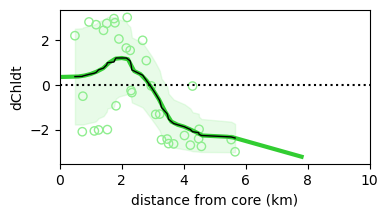

In [70]:
#smoothing
window=20
if len(dChldt_dataset)<20: window=10
    
moving_std_dChldt = dChldt_dataset['dChldt'].rolling(dist_from_core=window, center=True, min_periods=1).std()
moving_mean_dChldt = dChldt_dataset['dChldt'].rolling(dist_from_core=window, center=True, min_periods=1).mean()

#second round of smoothing
moving_std_dChldt = moving_std_dChldt.rolling(dist_from_core=window, center=True, min_periods=1).mean()
moving_mean_dChldt = moving_mean_dChldt.rolling(dist_from_core=window, center=True, min_periods=1).mean()

# extrapolate
#time_dim = moving_std_dChldt.time
idx=~np.isnan(moving_mean_dChldt.dist_from_core)
new_dist_from_core = np.arange(0,8,0.2)

dChldt_std_extrapolated = moving_std_dChldt[idx].interp(dist_from_core=new_dist_from_core,
                                                method='linear', kwargs={"fill_value": "extrapolate"})

dChldt_mean_extrapolated = moving_mean_dChldt[idx].interp(dist_from_core=new_dist_from_core,
                                                method='linear', kwargs={"fill_value": "extrapolate"})

# plot
plt.figure(figsize=(4,2))
dChldt_dataset['dChldt'].plot.scatter(x='dist_from_core',marker='o',facecolor='none',color='lightgreen',alpha=1)
dChldt_mean_extrapolated.plot(x='dist_from_core',color='limegreen',linewidth=3)
moving_mean_dChldt.plot(x='dist_from_core',color='k',linewidth=1)
plt.fill_between(dChldt_dataset['dist_from_core'], 
                 moving_mean_dChldt - moving_std_dChldt, 
                 moving_mean_dChldt + moving_std_dChldt, 
                 color='lightgreen', alpha=0.2, label='Mean ± Std')

plt.axhline(0,color='k',linestyle=':')
plt.ylabel('dChldt')
plt.xlabel('distance from core (km)')
plt.xlim(0,10)
#plt.ylim(-0.3,0.1)
plt.show();

### Vertical velocity w


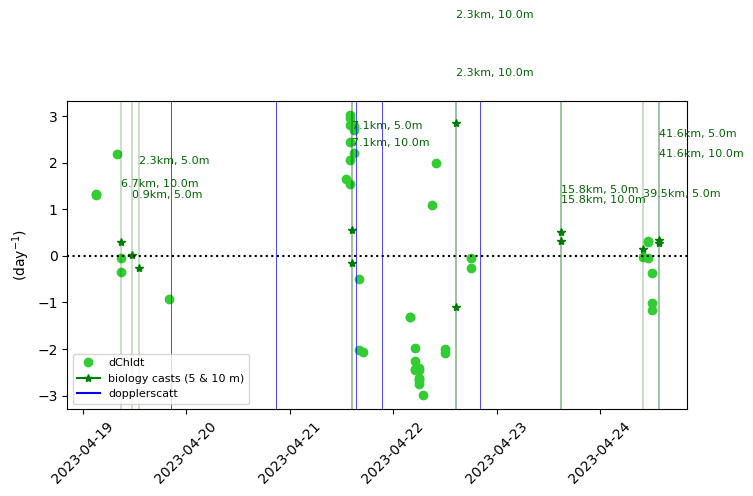

In [510]:
# load dopplerscatt
eddy_core_position = xr.open_dataset('eddy_core_position.nc')

ds = xr.open_dataset('dopplerscatt_gridded.nc')
ds = ds#.sel(lat=slice(36.7,37.1), lon=slice(-124.25,-123.8))
ds = ds.isel(time = slice(11,16))
ds


######
plt.figure(figsize=(8,4))

plt.plot(dChldt_dataset.time,dChldt_dataset.dChldt,'o',color='limegreen')
plt.plot(eddy_biology.time,(eddy_biology.growth+eddy_biology.grazing),'*g')
plt.xticks(rotation=45);

plt.plot([],[],'o',color='limegreen',label='dChldt')
plt.plot([],[],'-*',color='g',label='biology casts (5 & 10 m)')
plt.plot([],[],'-',color='b',label='dopplerscatt')

for t in eddy_biology.time.values:
    plt.axvline(t, linestyle='-', color='darkgreen', lw=0.3)
for t in ds.time.values:
    plt.axvline(np.datetime64(str(t)[0:21]), linestyle='-', color='b', lw=0.5)
for time, grazing, dist, depth in zip(eddy_biology.time, (eddy_biology.growth-eddy_biology.grazing).values, eddy_biology.dist_from_core, eddy_biology.depth):
    plt.text(time, grazing, f"{dist:.1f}km, {depth:.1f}m", fontsize=8, ha='left', va='bottom', color='darkgreen')
plt.axhline(0,c='k',linestyle=':')

plt.ylabel('(day$^{-1}$)')
plt.legend(fontsize=8)
plt.show();

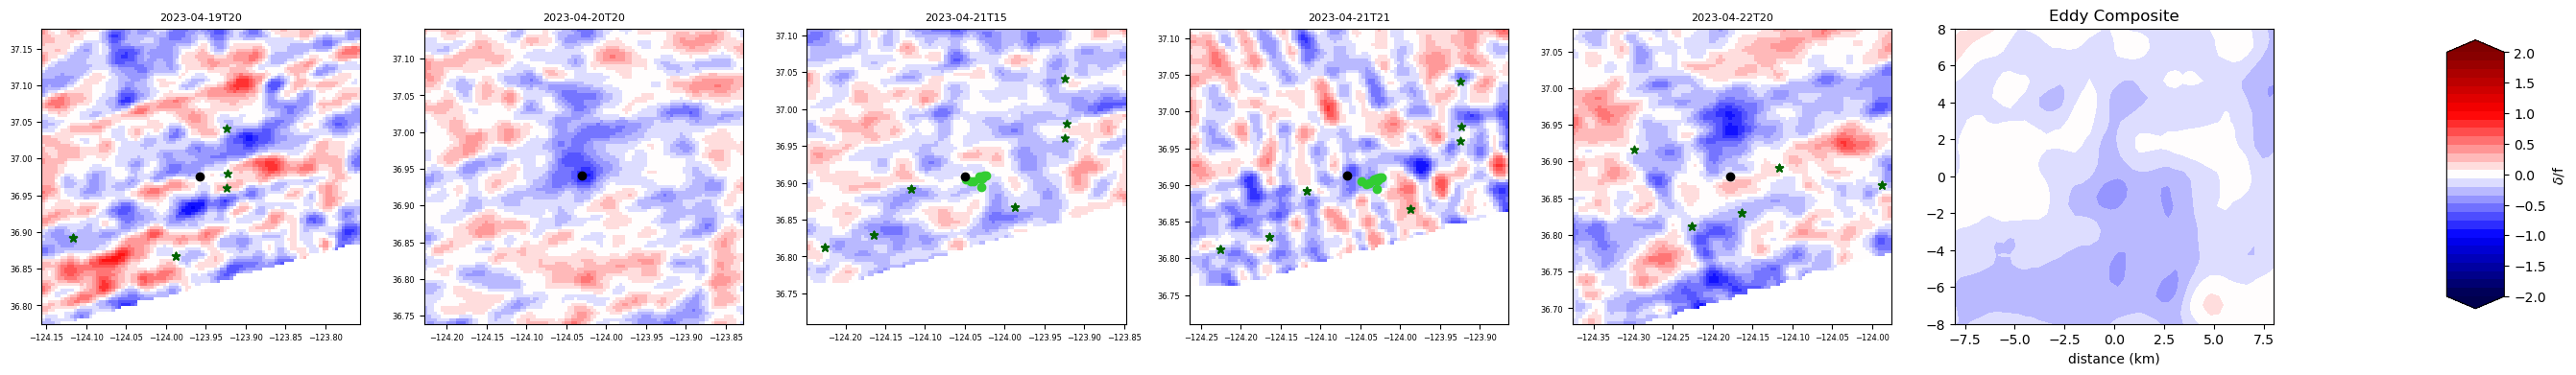

In [459]:
# create eddy composite

eddy_mid_value=[]
eddy_core_position = xr.open_dataset('eddy_core_position.nc')
vmin,vmax=-2,2
cmap='seismic'

fig, ax = plt.subplots(1,len(ds.time)+1,figsize=(len(ds.time)*6,4))

for i in range(ds.sizes['time']):
    f=coriolis_parameter(35)
    dsi = ds['divergence'].isel(time=i)/f
    itime = dsi.time.values
    lat=eddy_core_position.sel(time=str(itime)[0:13],method='nearest').lat
    lon=eddy_core_position.sel(time=str(itime)[0:13],method='nearest').lon
    
    f = coriolis_parameter(35)
    
    dlat,dlon=0.2,0.2#0.05,0.07
    eddy = dsi.sel(lat=slice(lat-dlat,lat+dlat),lon=slice(lon-dlon,lon+dlon))
    
    nlat, nlon = 100, 100  # Adjust these values as needed
    
    # create a regular grid
    lat_new = np.linspace(eddy.lat.min(), eddy.lat.max(), nlat)
    lon_new = np.linspace(eddy.lon.min(), eddy.lon.max(), nlon)
    
    # interpolate eddy onto the fixed grid
    eddy = eddy.interp(lat=lat_new, lon=lon_new)    
    if i==0:
        eddy_composite = eddy.values
    else: eddy_composite += eddy.values
        
    # keep divergence value
    L=len(eddy_composite)
    mid = int(np.round(L/2))
    eddy_mid_value.append(eddy[mid,mid].values)
    
    # plot each eddy
    if len(ax)>1: axis=ax.flatten()[i]
    else: axis=ax
    eddy.plot(levels=np.linspace(vmin,vmax,30), cmap=cmap, extend='both', add_colorbar=False, ax=axis)
    axis.plot(dsi.sel(lat=lat,lon=lon,method='nearest').lon, dsi.sel(lat=lat,lon=lon,method='nearest').lat, 'ok')
    axis.set_title(str(eddy.time.values)[0:13],fontsize=8)
    axis.tick_params(axis='x', labelsize=6); axis.tick_params(axis='y', labelsize=6);
    axis.set_xlabel(''); axis.set_ylabel('')
    
    # Filter dChldt and grazing points within ±X hour of DopplerScatt snapshot
    delta = np.timedelta64(10, 'h')

    dsi_time = np.datetime64(str(dsi.time.values)[0:21])
    dChldt_filtered = dChldt_dataset.where(
        (np.abs(dChldt_dataset.time - dsi_time) <= delta), drop=True
    )

    grazing_filtered = eddy_biology.where(
        (np.abs(eddy_biology.time - dsi_time) <= delta), drop=True
    )

    # Add filtered dChldt and grazing points
    axis.scatter(dChldt_filtered.lon, dChldt_filtered.lat, color='limegreen')
    axis.scatter(grazing_filtered.lon, grazing_filtered.lat, marker='*', color='darkgreen')
    
eddy_composite/=(i+1)

# x/y coordinates of composite
xlat=np.linspace(0,dlat*2,len(eddy.lat))
xlon=np.linspace(0,dlon*2,len(eddy.lon))
y_eddy = xlat * 111320 / 1e3
lat_midpoint = (eddy.lat[0] + eddy.lat[-1]) / 2  # Use the midpoint latitude for conversion
x_eddy = xlon * (111320 * np.cos(np.radians(lat_midpoint.values))) / 1e3

# plot eddy composite
axis=ax.flatten()[-1]
p=axis.contourf(np.mean(x_eddy)-x_eddy,np.mean(y_eddy)-y_eddy,eddy_composite,np.linspace(vmin,vmax,30),cmap=cmap,extend='both')
axis.set_title('Eddy Composite')
axis.set_xlabel('distance (km)')
axis.set_xlim(-8,8); axis.set_ylim(-8,8)

cbar_ax = fig.add_axes([0.96, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar=fig.colorbar(p, cax=cbar_ax)
cbar.set_ticks(np.linspace(vmin,vmax,9))
cbar.set_label(r'$\delta$/f',)


#plt.tight_layout()
plt.show();

from literature, vertical velocities should be ~10-100 m day-1

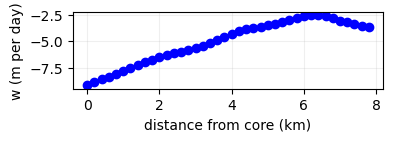

In [462]:
div = xr.open_dataset('div_eddy.nc').mean_divergence_by_distance*coriolis_parameter(35)
div_std = xr.open_dataset('div_eddy.nc').div_std*coriolis_parameter(35)

w_5m = 4*div # ACS measurements are at 4-m depth
w_5m_std = 4*div_std

w_5m_per_day = w_5m * 86400
w_5m_per_day_std = w_5m_std * 86400
# extrapolate
w_5m_per_day = w_5m_per_day.interp(dist_from_core=new_dist_from_core,
                                                method='quadratic', kwargs={"fill_value": "extrapolate"})
w_5m_per_day_std = w_5m_per_day_std.interp(dist_from_core=new_dist_from_core,
                                                method='quadratic', kwargs={"fill_value": "extrapolate"})
#plt.plot(xr.open_dataset('div_eddy.nc').dist_from_core, w_5m, 'ok')
#plt.show()

plt.figure(figsize=(4,1))
plt.plot(w_5m_per_day['dist_from_core'],w_5m_per_day,'o-b')#,edgecolor='w',color='b'); 
plt.ylabel('w (m per day)')
#plt.ylim(-20,0)
plt.grid(alpha=0.2)
plt.xlabel('distance from core (km)')
plt.show()

### dPdz

In [42]:
# Compute dPdz using the ACS

# ship data
mvp = xr.open_dataset('MVP.nc')

# ACS
TSG = xr.open_dataset('/Users/elise/data/SMODE-data/S_MODE_IOP2_SRIDE23_tsg_met_bio.nc')
TSG = TSG.drop_duplicates(dim='time_bio')
TSG = TSG.drop_duplicates(dim='time')
flowrate_time_bio = TSG['flow_rate_lab_tsg'].interp(time=TSG['time_bio'], method='linear')
TSG['flowrate_time_bio'] = (TSG.chlorophyll_ACS.dims, flowrate_time_bio.values)
TSG

# transects info and time periods
orientations = ['horizontal','vertical','vertical','horizontal','vertical']

# time we crossed the eddy
times_dopplerscatt=['2023-04-19T20','2023-04-20T20',
                  '2023-04-21T15','2023-04-21T21',
                  '2023-04-22T20','2023-04-24T20',]
time_crossing_intervals = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T21:55:00', '2023-04-22T23:40:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00']
]

orientations = orientations[2:4]
time_crossing_intervals = time_crossing_intervals[2:4]

mvp['rho'] = mvp.rho.where(mvp.salt >= 32.5)


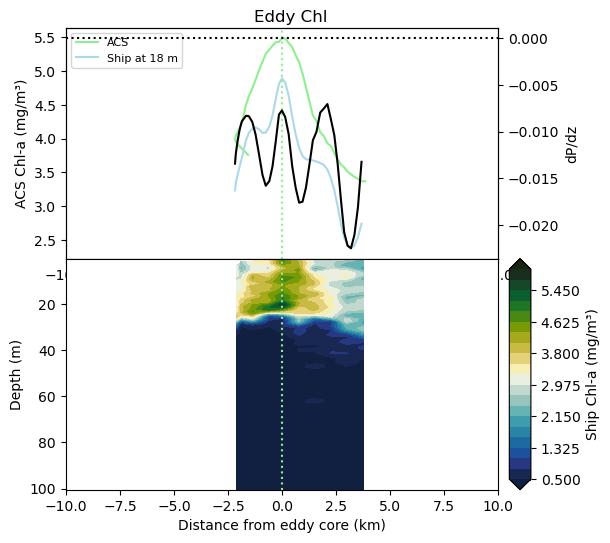

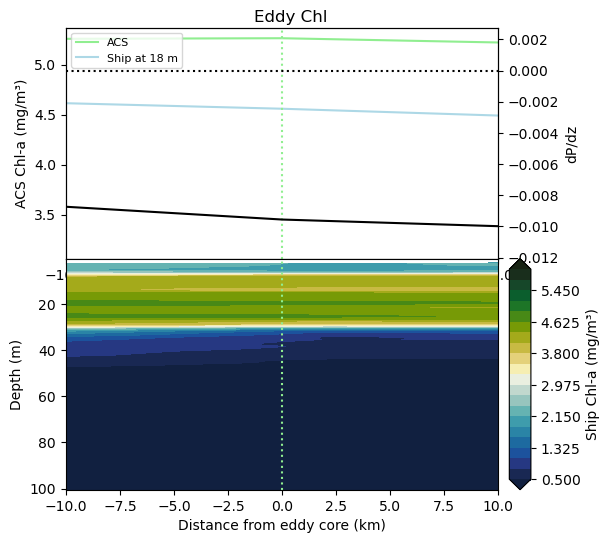

<xarray.Dataset> Size: 2kB
Dimensions:         (dist_from_core: 103)
Coordinates:
  * dist_from_core  (dist_from_core) float64 824B 0.0 0.0 0.1373 ... 271.0 271.1
Data variables:
    dPdz            (dist_from_core) float64 824B -0.007735 -0.009558 ... nan

In [44]:
dPdz_all = []
dist_from_core_all = []

for itransect in np.arange(len(time_crossing_intervals)):
    da_eddy = mvp.sel(time=slice(time_crossing_intervals[itransect][0],
                              time_crossing_intervals[itransect][1]))
    ACS_eddy = TSG['chlorophyll_ACS'].sel(time_bio=slice(time_crossing_intervals[itransect][0],
                              time_crossing_intervals[itransect][1]))
    ACS_eddy = ACS_eddy.rolling(time_bio=14,center=True,min_periods=1,).mean()
    
    icore = np.where(ACS_eddy==ACS_eddy.max())[0]
    
    if orientations[itransect]=='vertical': # zonal/latitude
        core_lat = ACS_eddy['latitude_bio'][icore]
        da_eddy = da_eddy.assign_coords(
            dist_from_core=111 * (core_lat.values - da_eddy['lat'])
        )
        ACS_eddy = ACS_eddy.assign_coords(
            dist_from_core=111 * (core_lat.values - ACS_eddy['latitude_bio'])
        )
    if orientations[itransect]=='horizontal': # meridional/longitude
        core_lon = ACS_eddy['longitude_bio'][icore]
        core_lat = da_eddy.lat.mean()
        R = 6371 # Earth's radius (km)
        da_eddy = da_eddy.assign_coords(
            dist_from_core = R * np.cos(np.deg2rad(core_lat)) * (core_lon.values - da_eddy['lon'])
        )
        ACS_eddy = ACS_eddy.assign_coords(
            dist_from_core = R * np.cos(np.deg2rad(core_lat)) * (core_lon.values - ACS_eddy['longitude_bio'])
        )
    
    # depth chl from ship
    z_ship = 18 # meters
    P_ship = da_eddy['chla'].sel(pressure=z_ship,method='nearest')
    
    # surface chl from ACS
    z_ACS = 4 # meters ## TO VERIFY !!!
    P_ACS = ACS_eddy
    
    # dPdz (interpolate ship time on ACS time)
    P_ship_on_ACS = P_ship.interp(time=ACS_eddy.time_bio, method='quadratic')
    dPdz = (P_ACS - P_ship_on_ACS) / (z_ACS - z_ship)
    dPdz = dPdz/P_ACS # in per day units
    
    # save for later
    dPdz_all.append(dPdz.values)
    dist_from_core_all.append(ACS_eddy['dist_from_core'].values)
    
    # Plot Chl with respect to eddy core
    plot=1
    if plot==1:
        import matplotlib.gridspec as gridspec
        
        fig = plt.figure(figsize=(6, 6))
        gs = gridspec.GridSpec(2, 2, width_ratios=[20, 1], height_ratios=[1, 1], hspace=0., wspace=0.05)
        
        # ACS chl
        ax0 = fig.add_subplot(gs[0, 0])
        ax0.plot(ACS_eddy['dist_from_core'], ACS_eddy, '-',color='lightgreen', label='ACS')
        ax0.axvline(0, color='w', linestyle=':')
        ax0.set_ylabel('ACS Chl-a (mg/m³)')
        #ax0.grid(alpha=0.3)
        #ax0.plot(P_ship['dist_from_core'],P_ship,'-',color='lightblue',label=f'Ship at {z_ship} m')
        ax0.plot(ACS_eddy['dist_from_core'],P_ship_on_ACS,'-',color='lightblue',label=f'Ship at {z_ship} m')
        ax0.legend(loc = 'upper left', fontsize=8)
        ax0_ = ax0.twinx()
        ax0_.plot(ACS_eddy['dist_from_core'], dPdz, '-k')
        ax0_.axhline(0,color='k',linestyle=':')
        ax0_.set_ylabel('dP/dz')
        
        # ship chl
        ax1 = fig.add_subplot(gs[1, 0])
        p = ax1.contourf(
            da_eddy['dist_from_core'], da_eddy['pressure'],
            da_eddy['chla'], np.linspace(0.5, 6, 21),
            cmap=cm.delta, extend='both'
        )
        ax1.invert_yaxis()
        ax1.set_xlabel('Distance from eddy core (km)')
        ax1.set_ylabel('Depth (m)')
        
        # colorbar
        cbar_ax = fig.add_subplot(gs[1, 1])  # Span both rows for the colorbar
        plt.colorbar(p, cax=cbar_ax, label='Ship Chl-a (mg/m³)')
            
        # title
        for axis in [ax0, ax1]:
            min_lim = np.max([ACS_eddy['dist_from_core'].min(), P_ship['dist_from_core'].min()])
            max_lim = np.min([ACS_eddy['dist_from_core'].max(), P_ship['dist_from_core'].max()])
            axis.set_xlim(min_lim,max_lim)
            axis.set_xlim(-10,10)
            axis.axvline(0,color='lightgreen',linestyle=':')
        plt.suptitle('Eddy Chl', y=0.91)
        plt.show()

dPdz_all = np.concatenate(dPdz_all)
dist_from_core_all = np.abs(np.concatenate(dist_from_core_all))

# create dataset
dPdz_dataset = xr.Dataset(
    {
    'dPdz': xr.DataArray(dPdz_all.flatten(),dims='dist_from_core'),
    'dist_from_core': xr.DataArray(dist_from_core_all, dims='dist_from_core'),
    },
)
dPdz_dataset = dPdz_dataset.sortby('dist_from_core')
dPdz_dataset

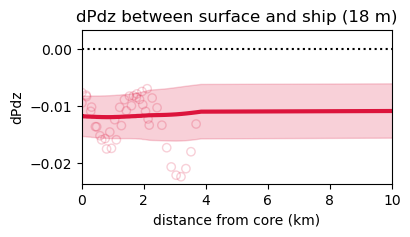

In [467]:
#smoothing
moving_std_dPdz = dPdz_dataset['dPdz'].rolling(dist_from_core=50, center=True, min_periods=1).std()
moving_mean_dPdz = dPdz_dataset['dPdz'].rolling(dist_from_core=50, center=True, min_periods=1).mean()

#second round of smoothing
moving_std_dPdz = moving_std_dPdz.rolling(dist_from_core=50, center=True, min_periods=1).mean()
moving_mean_dPdz = moving_mean_dPdz.rolling(dist_from_core=50, center=True, min_periods=1).mean()

# plot
plt.figure(figsize=(4,2))
dPdz_dataset['dPdz'].plot.scatter(marker='o',facecolor='none',color='crimson',alpha=0.2)
moving_mean_dPdz.plot(color='crimson',linewidth=3)
plt.fill_between(dPdz_dataset['dist_from_core'], 
                 moving_mean_dPdz - moving_std_dPdz, 
                 moving_mean_dPdz + moving_std_dPdz, 
                 color='crimson', alpha=0.2, label='Mean ± Std')

plt.axhline(0,color='k',linestyle=':')
plt.ylabel('dPdz')
plt.xlabel('distance from core (km)')
plt.xlim(0,10)
#plt.ylim(-0.3,0.1)
plt.title(f'dPdz between surface and ship ({z_ship} m)')
plt.show();

In [469]:
def interpolate_chla(da_eddy):
    from scipy.interpolate import interpn
    
    # New grid
    dist_new = np.linspace(-10, 10, 500)  # 500 points for distance
    pressure_new = np.linspace(0, 40, 100)  # 100 points for pressure
    
    # 2D grid for interpolation
    dist_grid, pressure_grid = np.meshgrid(dist_new, pressure_new)
    
    # Original data
    dist_from_core = da_eddy['dist_from_core'].values
    pressure = da_eddy['pressure'].values
    points = (pressure, dist_from_core)
    
    # Chlorophyll data
    chla_values = da_eddy['chla'].values
    
    # Interpolation
    chla_interpolated = interpn(
        points, chla_values,
        np.array([pressure_grid.ravel(), dist_grid.ravel()]).T,  # Reshape new grid for interpolation
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    ).reshape(pressure_grid.shape)  # Reshape to the new grid's shape
    
    # Create dataArray
    da_eddy_interpolated = xr.Dataset(
        {
            "chla": (["pressure", "dist_from_core"], chla_interpolated),
        },
        coords={
            "dist_from_core": dist_new,
            "pressure": pressure_new,
        }
    )
    
    return da_eddy_interpolated

## w$\times$dPdz

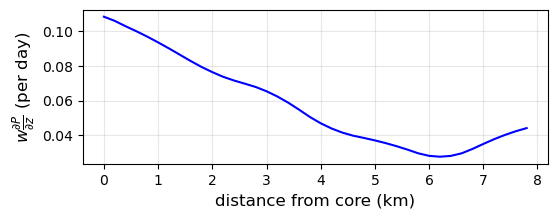

In [471]:
# mean
unique_values, unique_indices = np.unique(moving_mean_dPdz.dist_from_core, return_index=True)
dPdz_mean = moving_mean_dPdz[np.sort(unique_indices)]

# std
dPdz_std = moving_std_dPdz[np.sort(unique_indices)]

# interp
dPdz_mean_interp = dPdz_mean.interp(dist_from_core=new_dist_from_core,method='quadratic',
                            kwargs={"fill_value": "extrapolate"})
dPdz_std_interp = dPdz_std.interp(dist_from_core=new_dist_from_core,method='quadratic',
                            kwargs={"fill_value": "extrapolate"})
w_5m_per_day_interp_on_dPdz = w_5m_per_day.interp(dist_from_core=new_dist_from_core,method='quadratic',
                            kwargs={"fill_value": "extrapolate"})
w_5m_per_day_std_interp_on_dPdz = w_5m_per_day_std.interp(dist_from_core=new_dist_from_core,method='quadratic',
                            kwargs={"fill_value": "extrapolate"})
wdPdz =  w_5m_per_day_interp_on_dPdz * dPdz_mean_interp

#wdPdz=wdPdz.isel(dist_from_core=wdPdz['dist_from_core']<=12)
wdPdz.plot(x='dist_from_core',c='b',figsize=(6,2))
plt.xlabel('distance from core (km)',fontsize=12)
plt.ylabel(r'$w\frac{\partial P}{\partial z}$ (per day)',fontsize=12)
#plt.xlim(0,10); plt.ylim(0,0.2)
plt.grid(alpha=0.3)
plt.title('');

In [472]:
# standard error of w* dP/dz
def product_error(x, y, sigma_x, sigma_y):
    z = x * y
    rel_error = np.sqrt((sigma_x / x)**2 + (sigma_y / y)**2)
    sigma_z = z * rel_error
    return z, sigma_z

x, sigma_x = w_5m_per_day_interp_on_dPdz, w_5m_per_day_std_interp_on_dPdz
y, sigma_y = dPdz_mean_interp, dPdz_std_interp

# Product
z, wdPdz_std = product_error(x, y, sigma_x, sigma_y)

### All together

In [474]:
# Distance and values for each budget term
growth_dist = eddy_biology.dist_from_core
growth_values = eddy_biology.growth
growth_se_values = eddy_biology.growth_se

grazing_dist = eddy_biology.dist_from_core
grazing_values = -eddy_biology.grazing
grazing_se_values = eddy_biology.grazing_se

dChldt_dist_core = dChldt_mean_extrapolated['dist_from_core']#dChldt_dataset['dist_from_core'].values#dChldt_extrapolated['dist_from_core']#dChldt.dist_from_core
dChldt_values = dChldt_mean_extrapolated#dChldt_dataset['dChldt'].values

dChldt_std_dist  = dChldt_std_extrapolated['dist_from_core']
dChldt_std_values= dChldt_std_extrapolated

wdPdz_dist = wdPdz['dist_from_core']
wdPdz_values = -wdPdz
wdPdz_std_values = wdPdz_std

# Define the bin edges
dbin= 1# km
bin_edges = np.arange(0,12,dbin) 
bin_centers = bin_edges[:-1] + dbin/2  # Center of each bin

# Function to bin data
def bin_data(dist, values, bin_edges):
    bins = np.digitize(dist, bin_edges) - 1  # Assign each value to a bin
    binned_means = np.array([values[bins == i].mean() if any(bins == i) else np.nan for i in range(len(bin_centers))])
    binned_stds = np.array([values[bins == i].std() if any(bins == i) else np.nan for i in range(len(bin_centers))])
    return binned_means, binned_stds

# Bin each term
binned_growth_values, binned_growth_std = bin_data(growth_dist, growth_values, bin_edges)
binned_grazing_values, binned_grazing_std = bin_data(grazing_dist, grazing_values, bin_edges)
binned_dChldt_values = np.interp(bin_centers, dChldt_dist_core, dChldt_values)
binned_dChldt_std = np.interp(bin_centers, dChldt_std_dist, dChldt_std_values)
binned_wdPdz_values, binned_wdPdz_std = bin_data(wdPdz_dist, wdPdz_values, bin_edges)

# Compute residual
residual = binned_dChldt_values - binned_growth_values + binned_grazing_values + binned_wdPdz_values
residual_std = np.sqrt(binned_dChldt_std**2 + binned_growth_std**2 + binned_grazing_std**2 + binned_wdPdz_std**2)


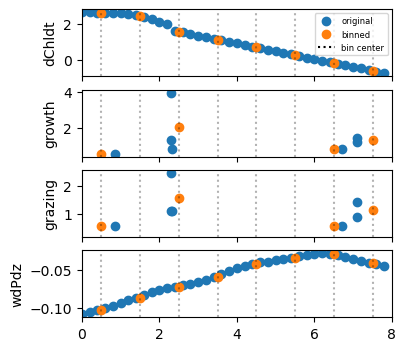

In [475]:
fig,ax = plt.subplots(4,1,figsize=(4,4),sharex=True)
axis=ax.flatten()[0]
axis.plot(dChldt_dist_core,dChldt_values,'o',label='original')
axis.plot(bin_centers,binned_dChldt_values, 'o',label='binned')
axis.set_ylabel('dChldt')

axis=ax.flatten()[1]
axis.plot(growth_dist,growth_values,'o')
axis.plot(bin_centers,binned_growth_values, 'o')
axis.set_ylabel('growth')

axis=ax.flatten()[2]
axis.plot(grazing_dist,grazing_values,'o')
axis.plot(bin_centers,binned_grazing_values, 'o')
axis.set_ylabel('grazing')

axis=ax.flatten()[3]
axis.plot(wdPdz_dist,wdPdz_values,'o')
axis.plot(bin_centers,binned_wdPdz_values, 'o')
axis.set_ylabel('wdPdz')


for axis in ax.flatten():
    axis.set_xlim(0,8)
    for i in range(len(bin_centers)):
        axis.axvline(bin_centers[i],color='k',linestyle=':',alpha=0.3)


ax[0].axvline(-2,color='k',linestyle=':',label='bin center')
ax[0].legend(fontsize=6)
plt.show()

In [476]:
n=(~np.isnan(binned_growth_values + binned_grazing_values + 
             binned_dChldt_values + binned_wdPdz_values)).sum()
print(n)

4


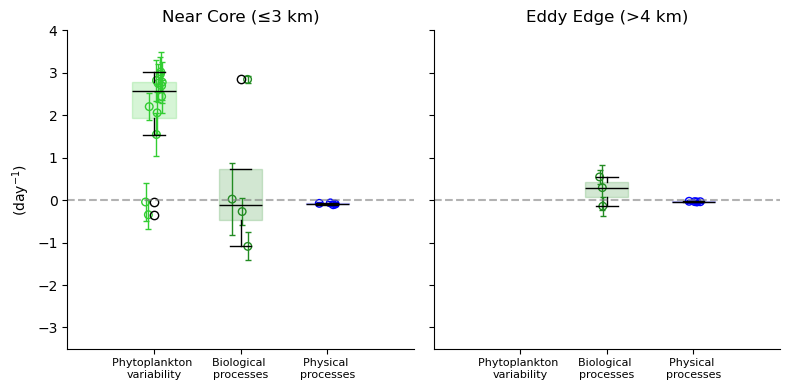

In [494]:
dChldt_values    = dChldt_dataset['dChldt'][~np.isnan(dChldt_dataset['dChldt'])]
dChldt_dist_core = dChldt_dataset['dist_from_core'][~np.isnan(dChldt_dataset['dChldt'])]
dChldt_dist_ship = dChldt_dataset['dist_from_ship'][~np.isnan(dChldt_dataset['dChldt'])]

# Compute Biology = Growth - Grazing
biology_values = growth_values - grazing_values

# Define bins
core_threshold = 3  # km
eddy_threshold = 4  # km

core_mask_dChldt = dChldt_dist_core <= core_threshold
outer_mask_dChldt = (dChldt_dist_core > eddy_threshold) & (dChldt_dist_core<15)

core_mask_biology = (grazing_dist <= core_threshold).values
outer_mask_biology = (grazing_dist > eddy_threshold).values & (grazing_dist < 15).values

core_mask_physics = wdPdz_dist <= core_threshold
outer_mask_physics = wdPdz_dist > eddy_threshold

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# Function to plot with separate masks
def plot_budget(ax, region_label, mask_dChldt, mask_biology, mask_physics):
   
    # dChldt (Total)
    dChldt_unique, idx = np.unique(dChldt_values[mask_dChldt], return_index=True)
    dChldt_err = 0.38 * dChldt_dist_ship[idx] + 0.15
    #dChldt = np.unique(dChldt_values[mask_dChldt])#[~np.isnan(dChldt_values[mask_dChldt])])
    L = len(dChldt_unique)
    x_jittered = np.full(L, 1) + np.random.uniform(-0.1, 0.1, L)
    
    ax.scatter(x_jittered, dChldt_unique, s=30, marker='o', 
               edgecolor='limegreen', facecolor='none', label=r'$\frac{dChl}{dt}$ (Total)')
    ax.errorbar(x_jittered, dChldt_unique, yerr=dChldt_err, fmt='none', markersize=5,
                markerfacecolor='none', markeredgecolor='limegreen',
                ecolor='limegreen', elinewidth=1, capsize=2,
                )
    
    ax.boxplot(
        dChldt_unique, 
        positions=[1],
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="limegreen", edgecolor='limegreen', alpha=0.2),
        whiskerprops=dict(color="k", linewidth=1), 
        capprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1) 
    )
    
    # Biology (Growth - Grazing)
    L = len(biology_values[mask_biology])
    x_jittered = np.full(L, 2)+ np.random.uniform(-0.1, 0.1, L)
    bio_err = np.sqrt(grazing_se_values**2 + grazing_se_values**2)[mask_biology]
    ax.scatter(
        x_jittered,  # Jittered x-position for Biology
        biology_values[mask_biology],
        s=30, edgecolor='forestgreen', marker='o', facecolor='none', label='Biology (Growth - Grazing)'
    )
    ax.errorbar(x_jittered, biology_values[mask_biology], yerr=bio_err, fmt='none', markersize=5,
                markerfacecolor='none', markeredgecolor='forestgreen',
                ecolor='forestgreen', elinewidth=1, capsize=2,
                )
    
    ax.boxplot(
    biology_values[mask_biology][~np.isnan(biology_values[mask_biology])], 
    positions=[2],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="forestgreen", edgecolor='forestgreen', alpha=0.2),
    whiskerprops=dict(color="k", linewidth=1), 
    capprops=dict(color="k", linewidth=1),
    medianprops=dict(color="k", linewidth=1) 
    )
    
    # Physics (wdPdz) -- negative
    L = len(wdPdz_values[mask_physics])
    x_jittered = np.full(L, 3)+ np.random.uniform(-0.1, 0.1, L)
    phys_err = wdPdz_std_values[mask_physics]
    ax.scatter(
        x_jittered[::5],  # Jittered x-position for Physics
        wdPdz_values[mask_physics][::5],
        s=30, edgecolor='blue', marker='o', facecolor='none', label='Physics (wdPdz)'
    )
    ax.errorbar(x_jittered[::5], wdPdz_values[mask_physics][::5], yerr=phys_err[::5], fmt='none', markersize=5,
                markerfacecolor='none', markeredgecolor='b',
                ecolor='b', elinewidth=1, capsize=2,
                )

    ax.boxplot(
    wdPdz_values[mask_physics][~np.isnan(wdPdz_values[mask_physics])], 
    positions=[3],
    widths=0.5,
    patch_artist=True,
    boxprops=dict(facecolor="blue", edgecolor='blue', alpha=0.2),
    whiskerprops=dict(color="k", linewidth=1), 
    capprops=dict(color="k", linewidth=1),
    medianprops=dict(color="k", linewidth=1) 
    )
    
    ax.axhline(0, linestyle='--', color='gray', alpha=0.6)
    ax.set_title(region_label)
    #ax.legend()
    ax.set_xlim(0,4)
    ax.set_xticks([1,2,3],)
    ax.set_xticklabels(['Phytoplankton \nvariability','Biological \nprocesses','Physical \nprocesses'],
                       fontsize=8,rotation=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    #ax.set_ylim(-1,1)

# Plot near core
plot_budget(axes[0], f"Near Core (≤{core_threshold} km)", core_mask_dChldt, core_mask_biology, core_mask_physics)

# Plot away from core
plot_budget(axes[1], f"Eddy Edge (>{eddy_threshold} km)", outer_mask_dChldt, outer_mask_biology, outer_mask_physics)

axes[0].set_ylabel("(day$^{-1}$)")

for axis in axes: axis.set_ylim(-3.5,4)
plt.tight_layout()

#plt.savefig('/Users/elise/Desktop/FIG4_1h.png',dpi=800,transparent=True)

plt.show()

## Old way

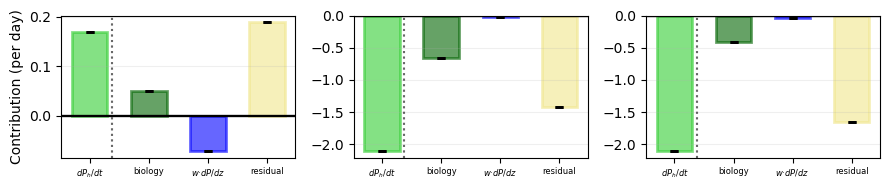

In [383]:
budget = xr.Dataset({
    "dChldt_binned": ("bin", binned_dChldt_values),
    "bio_binned": ("bin", binned_growth_values-binned_grazing_values),
    "wdPdz_binned": ("bin", -binned_wdPdz_values),
    "residual_binned": ("bin", residual),

    "dChldt_error": ("bin", binned_dChldt_std),
    "bio_error": ("bin", binned_growth_std+binned_grazing_std),
    "wdPdz_error": ("bin", binned_wdPdz_std),
    "residual_error": ("bin", residual_std),
    
}, coords={"bin": bin_centers})

# Drop bins without data
budget = budget.dropna(dim="bin")

# Bar plot
terms = [f"{term}_binned" for term in ["dChldt", "bio", "wdPdz", "residual"]]
errors = [f"{term}_error" for term in ["dChldt", "bio", "wdPdz", "residual"]]
labels = [r"$dP_h/dt$", "biology", r"$w·dP/dz$", "residual"]
colors = ["limegreen", "darkgreen", "blue", "khaki"]
width = 0.16  # Fixed bar width

x = np.arange(len(budget['bin']))  # Bin indices for x-axis
offsets = np.linspace(-0.4, 0.4, len(terms))  # Spread bars evenly within each bin

fig, axes = plt.subplots(1,n,figsize=(3*n,2))#, sharey=True)

for (ax,bin) in zip(axes,np.arange(n)):
    

    for i, (term, error, label, color) in enumerate(zip(terms, errors, labels, colors)):
        ax.bar(x[0] + offsets[i], budget.isel(bin=bin)[term], width, yerr=budget.isel(bin=bin)[error]*0., 
               label=label, color=color, edgecolor=color, alpha=0.6, linewidth=2, 
                error_kw=dict(lw=2, capsize=3, capthick=2))
    
        ax.axhline(0, color='k')
        ax.axvline(-0.3, color='k', linestyle=':', alpha=0.2)
        #ax.set_xticks(x); ax.set_xticklabels([f"{b:.1f}" for b in budget['bin'].values])
        ax.set_xticks([0.4,0.133,-0.133,-0.4,][::-1],)
        ax.set_xticklabels(labels,fontsize=6,rotation=0)
        #ax.set_xlabel("Distance from Core (km)")
        
        #ax.legend(loc="best")
        ax.yaxis.grid(alpha=0.2)
        #plt.title("Budget Analysis")
        #print(ax,bin,i,term)
        #ax.set_ylim(-1,1)
axes[0].set_ylabel("Contribution (per day)")

plt.tight_layout()
#plt.savefig('/Users/elise/Desktop/FIG4.png',dpi=800)

plt.show()

In [762]:
TSG

<xarray.Dataset> Size: 40MB
Dimensions:                              (time_bio: 32509, time: 147912,
                                          instrument: 1)
Coordinates:
  * time_bio                             (time_bio) datetime64[ns] 260kB 2023...
    latitude_bio                         (time_bio) float64 260kB ...
    longitude_bio                        (time_bio) float64 260kB ...
  * time                                 (time) datetime64[ns] 1MB 2023-04-07...
    latitude                             (time) float64 1MB ...
    longitude                            (time) float64 1MB ...
Dimensions without coordinates: instrument
Data variables: (12/47)
    TSG86                                (instrument) float64 8B ...
    TSG73                                (instrument) float64 8B ...
    SST62                                (instrument) float64 8B ...
    FLW19                                (instrument) float64 8B ...
    FLW20                                (instrument) float64 8B ...
    FLW09                                (instrument) float64 8B ...
    ...                                   ...
    beam_attenuation_657nm_ACS           (time_bio) float64 260kB ...
    chlorophyll_flourometer              (time_bio) float64 260kB ...
    particulate_organic_carbon_cstar     (time_bio) float64 260kB ...
    photosynthetically_active_radiation  (time_bio) float64 260kB ...
    CSTAR_QCflag                         (time_bio) float64 260kB ...
    flowrate_time_bio                    (time_bio) float64 260kB 2.844 ... 1...
Attributes: (12/52)
    DOI:                           10.5067/SMODE-RVTSG
    title:                         SMODE Shipboard bio-optical, meteorlogical...
    summary:                       Level-2 processed data from GPS, TSG and F...
    keywords:                      EARTH SCIENCE > OCEANS > OPTICS > ATTENUAT...
    keywords_vocabulary:           NASA Global Change Master Directory (GCMD)...
    conventions:                   CF-1.8, ACDD-1.3
    ...                            ...
    timetime_coverage_end:         2023-05-03T15:05:07Z
    geospatial_vertical_units:     m
    geospatial_vertical_positive:  down
    date_created:                  2023-04-13T00:00:00Z
    time_coverage_duration:        P25D20H10M57S
    comment:                       See readme.txt. Thermosalinograph Data are...